

 PANDAS ANALYSIS & VISUALIZATION PROGRAM 
1. Load Dataset
2. Explore Data
3. Handle Missing Values
4. Generate Descriptive Statistics
5. Filter Data
6. GroupBy Operations
7. Sort Data
8. Data Visualization
9. Save Processed Data
10. Exit

Enter your choice: 1

✅ Dataset Loaded Successfully!

         sale_id   sale_date  year quarter      month    country  \
0  SAMS-00000001  2021-01-01  2021      Q1    January  Argentina   
1  SAMS-00000002  2021-03-23  2021      Q1      March  Argentina   
2  SAMS-00000003  2021-05-22  2021      Q2        May  Argentina   
3  SAMS-00000004  2021-07-26  2021      Q3       July  Argentina   
4  SAMS-00000005  2021-09-02  2021      Q3  September  Argentina   

          region          city                 product_name    category  ...  \
0  South America  Buenos Aires  Samsung Galaxy Tab S9 Ultra  Galaxy Tab  ...   
1  South America  Buenos Aires           Samsung Galaxy S23    Galaxy S  ...   
2  South America  Buenos Aires        Samsung Galaxy A34

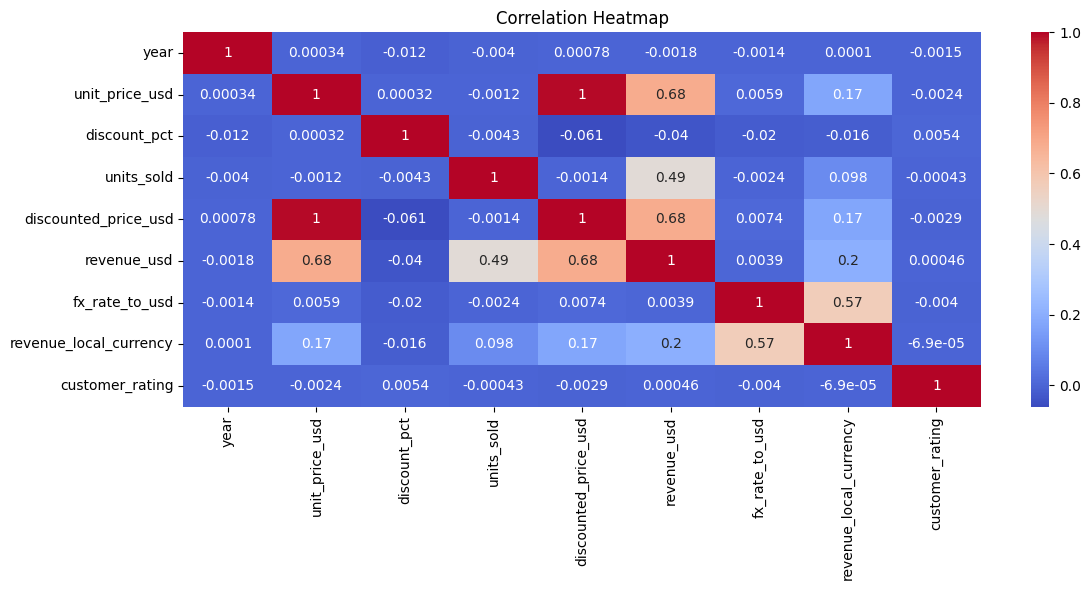


========== VISUALIZATION MENU ==========
1. Line Plot
2. Bar Plot
3. Histogram
4. Scatter Plot
5. Pie Chart
6. Correlation Heatmap
7. Back


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


class DataAnalyzer:

    def __init__(self):

        self.file_path = "/content/samsung_global_sales_dataset.csv"

        self.df = None

    def load_data(self):

        try:

            self.df = pd.read_csv(self.file_path)

            print("\n✅ Dataset Loaded Successfully!\n")

            print(self.df.head())

            print(f"\nDataset Shape: {self.df.shape}")

        except FileNotFoundError:
            print("❌ CSV file not found.")

        except Exception as e:
            print(f"❌ Error: {e}")

    def explore_data(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\n========== DATASET INFO ==========")
        print(self.df.info())

        print("\n========== FIRST 5 ROWS ==========")
        print(self.df.head())

        print("\n========== LAST 5 ROWS ==========")
        print(self.df.tail())

        print("\n========== SHAPE ==========")
        print(f"Rows: {self.df.shape[0]}")
        print(f"Columns: {self.df.shape[1]}")

        print("\n========== COLUMN NAMES ==========")
        print(self.df.columns.tolist())

        print("\n========== DATA TYPES ==========")
        print(self.df.dtypes)

        print("\n========== MISSING VALUES ==========")
        print(self.df.isnull().sum())

    def handle_missing_values(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\nMissing Values Before Cleaning:\n")
        print(self.df.isnull().sum())

        print("\n1. Drop Missing Values")
        print("2. Fill Numeric Missing Values with Mean")

        choice = input("\nEnter choice: ")

        if choice == '1':

            self.df.dropna(inplace=True)

            print("\n✅ Missing values removed successfully.")

        elif choice == '2':

            numeric_cols = self.df.select_dtypes(include=np.number).columns

            for col in numeric_cols:
                self.df[col] = self.df[col].fillna(
                    self.df[col].mean()
                )

            print("\n✅ Missing values filled successfully.")

        else:
            print("❌ Invalid choice.")

        print("\nMissing Values After Cleaning:\n")
        print(self.df.isnull().sum())

    def descriptive_statistics(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\n========== DESCRIPTIVE STATISTICS ==========")

        print(self.df.describe(include='all'))

    def filter_data(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\nColumns:")
        print(self.df.columns.tolist())

        column = input("\nEnter column name for filtering: ")

        if column not in self.df.columns:
            print("❌ Invalid column name.")
            return

        value = input("Enter value to filter: ")

        filtered_df = self.df[
            self.df[column].astype(str) == value
        ]

        print("\n========== FILTERED DATA ==========")

        print(filtered_df)

    def groupby_operations(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\nColumns:")
        print(self.df.columns.tolist())

        group_col = input("\nEnter group column: ")
        agg_col = input("Enter numeric column: ")

        if group_col not in self.df.columns:
            print("❌ Invalid group column.")
            return

        if agg_col not in self.df.columns:
            print("❌ Invalid aggregation column.")
            return

        try:

            grouped_data = self.df.groupby(group_col)[agg_col].mean()

            print("\n========== GROUPBY RESULT ==========")

            print(grouped_data)

        except Exception as e:
            print(f"❌ Error: {e}")

    def sort_data(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\nColumns:")
        print(self.df.columns.tolist())

        column = input("\nEnter column name for sorting: ")

        if column not in self.df.columns:
            print("❌ Invalid column name.")
            return

        order = input("Ascending order? (yes/no): ").lower()

        ascending = True if order == 'yes' else False

        sorted_df = self.df.sort_values(
            by=column,
            ascending=ascending
        )

        print("\n========== SORTED DATA ==========")

        print(sorted_df.head(20))

    def visualize_data(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        while True:

            print("\n========== VISUALIZATION MENU ==========")

            print("1. Line Plot")
            print("2. Bar Plot")
            print("3. Histogram")
            print("4. Scatter Plot")
            print("5. Pie Chart")
            print("6. Correlation Heatmap")
            print("7. Back")

            choice = input("\nEnter your choice: ")

            try:


                if choice == '1':

                    x_col = input("Enter X-axis column: ")
                    y_col = input("Enter Y-axis column: ")

                    plt.figure(figsize=(12, 6))

                    plt.plot(
                        self.df[x_col],
                        self.df[y_col],
                        marker='o'
                    )

                    plt.title('Line Plot')
                    plt.xlabel(x_col)
                    plt.ylabel(y_col)

                    plt.grid(True)

                    plt.tight_layout()

                    plt.show()


                elif choice == '2':

                    x_col = input("Enter categorical column: ")
                    y_col = input("Enter numeric column: ")

                    plt.figure(figsize=(12, 6))

                    sns.barplot(
                        x=self.df[x_col],
                        y=self.df[y_col]
                    )

                    plt.title('Bar Plot')

                    plt.xticks(rotation=45)

                    plt.tight_layout()

                    plt.show()


                elif choice == '3':

                    column = input("Enter numeric column: ")

                    plt.figure(figsize=(12, 6))

                    plt.hist(
                        self.df[column],
                        bins=10
                    )

                    plt.title('Histogram')

                    plt.xlabel(column)
                    plt.ylabel('Frequency')

                    plt.tight_layout()

                    plt.show()


                elif choice == '4':

                    x_col = input("Enter X-axis column: ")
                    y_col = input("Enter Y-axis column: ")

                    plt.figure(figsize=(12, 6))

                    plt.scatter(
                        self.df[x_col],
                        self.df[y_col]
                    )

                    plt.title('Scatter Plot')

                    plt.xlabel(x_col)
                    plt.ylabel(y_col)

                    plt.tight_layout()

                    plt.show()


                elif choice == '5':

                    column = input("Enter categorical column: ")

                    pie_data = self.df[column].value_counts()

                    plt.figure(figsize=(12, 6))

                    plt.pie(
                        pie_data,
                        labels=pie_data.index,
                        autopct='%1.1f%%'
                    )

                    plt.title('Pie Chart')

                    plt.tight_layout()

                    plt.show()


                elif choice == '6':

                    numeric_df = self.df.select_dtypes(
                        include=np.number
                    )

                    if numeric_df.empty:
                        print("❌ No numeric columns found.")
                        continue

                    plt.figure(figsize=(12, 6))

                    sns.heatmap(
                        numeric_df.corr(),
                        annot=True,
                        cmap='coolwarm'
                    )

                    plt.title('Correlation Heatmap')

                    plt.tight_layout()

                    plt.show()


                elif choice == '7':
                    break

                else:
                    print("❌ Invalid choice.")

            except Exception as e:
                print(f"❌ Visualization Error: {e}")

    def save_data(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        output_file = "processed_data.csv"

        try:

            self.df.to_csv(output_file, index=False)

            print(
                f"\n✅ Dataset saved successfully as {output_file}"
            )

        except Exception as e:
            print(f"❌ Error: {e}")



def main():

    analyzer = DataAnalyzer()

    while True:

        print("\n")
        print("=" * 55)
        print(" PANDAS ANALYSIS & VISUALIZATION PROGRAM ")
        print("=" * 55)

        print("1. Load Dataset")
        print("2. Explore Data")
        print("3. Handle Missing Values")
        print("4. Generate Descriptive Statistics")
        print("5. Filter Data")
        print("6. GroupBy Operations")
        print("7. Sort Data")
        print("8. Data Visualization")
        print("9. Save Processed Data")
        print("10. Exit")

        choice = input("\nEnter your choice: ")

        if choice == '1':
            analyzer.load_data()

        elif choice == '2':
            analyzer.explore_data()

        elif choice == '3':
            analyzer.handle_missing_values()

        elif choice == '4':
            analyzer.descriptive_statistics()

        elif choice == '5':
            analyzer.filter_data()

        elif choice == '6':
            analyzer.groupby_operations()

        elif choice == '7':
            analyzer.sort_data()

        elif choice == '8':
            analyzer.visualize_data()

        elif choice == '9':
            analyzer.save_data()

        elif choice == '10':

            print("\n✅ Exiting program... Goodbye!")

            break

        else:
            print("❌ Invalid choice.")



if __name__ == '__main__':
    main()